In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------
# -------------------- CONFIG ---------------------
# -------------------------------------------------
DATA_PATH = Path("Rn_DL_data_cleaned_final.xlsx")

COLMAP = {
    "date": "Date",
    "time": "Time",
    "region": "Location",
    "radon": "Rn_Bqm3",
    "salinity": "ctdsal",
    "temperature": "ctdtemp_C",
    "depth": "depth_m",
}

# Years of interest
FL_YEARS = [2005, 2006, 2007]

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# -------------------------------------------------
# -------------------- HELPERS --------------------
# -------------------------------------------------
def to_float(series):
    return pd.to_numeric(series.astype(str).str.replace(",", ".", regex=False), errors="coerce")

# -------------------------------------------------
# -------------------- LOAD -----------------------
# -------------------------------------------------
raw = pd.read_excel(DATA_PATH)
data = pd.DataFrame()

# Robust parsing of Date/Time into components
date_str = raw[COLMAP["date"]].astype(str).str.strip()
time_str = raw[COLMAP["time"]].astype(str).str.strip()
time_str = time_str.str.replace(r'^(\d{1}):', r'0\1:', regex=True)  # pad single-digit hour
time_str = time_str.where(time_str.ne(""), np.nan)

dt_combo = pd.to_datetime((date_str + " " + time_str).str.strip(), errors="coerce")
dt_date_only = pd.to_datetime(date_str, errors="coerce")
dt_final = dt_combo.fillna(dt_date_only)

# Extract components
data["year"]   = dt_final.dt.year
data["month"]  = dt_final.dt.month
data["day"]    = dt_final.dt.day
data["hour"]   = dt_final.dt.hour
data["minute"] = dt_final.dt.minute

data["region"] = raw[COLMAP["region"]].astype(str).str.strip()
data["radon"] = to_float(raw[COLMAP["radon"]])
data["salinity"] = to_float(raw[COLMAP["salinity"]]) if COLMAP["salinity"] in raw.columns else np.nan
data["temperature"] = to_float(raw[COLMAP["temperature"]]) if COLMAP["temperature"] in raw.columns else np.nan
data["depth"] = to_float(raw[COLMAP["depth"]]) if COLMAP["depth"] in raw.columns else np.nan

# Drop rows missing essentials
data = data.dropna(subset=["year", "radon"]).copy()

# Filter Florida
reg = data["region"].astype(str).str.strip().str.lower()
fl_df = data[reg.eq("florida")].copy()

# Keep only data from 2005, 2006, 2007
fl_sel = fl_df[fl_df["year"].isin(FL_YEARS)].copy()

# Cleaned Florida rows ready for regression
cols = ["region", "radon", "salinity", "temperature", "depth", "year", "month", "day", "hour", "minute"]
fl_clean_2005_2007 = (
    fl_sel[cols]
    .sort_values(["year", "month", "day", "hour", "minute"])
    .reset_index(drop=True)
)

fl_clean_2005_2007.head()


,region,radon,salinity,temperature,depth,year,month,day,hour,minute
0,Florida,49.57,33.65,17.14,1.41,2005,11,18,16,9
1,Florida,53.72,33.65,16.95,1.40,2005,11,18,17,9
2,Florida,51.37,33.66,17.14,1.39,2005,11,18,18,9
3,Florida,50.02,33.70,16.76,1.36,2005,11,18,19,9
4,Florida,51.81,33.72,16.57,1.35,2005,11,18,20,9


In [2]:
df = fl_clean_2005_2007.drop(['region', 'depth'], axis=1)
df.head()


,radon,salinity,temperature,year,month,day,hour,minute
0,49.57,33.65,17.14,2005,11,18,16,9
1,53.72,33.65,16.95,2005,11,18,17,9
2,51.37,33.66,17.14,2005,11,18,18,9
3,50.02,33.70,16.76,2005,11,18,19,9
4,51.81,33.72,16.57,2005,11,18,20,9


In [3]:
df['Time'] = np.arange(len(df.index))

In [4]:
df.head()

,radon,salinity,temperature,year,month,day,hour,minute,Time
0,49.57,33.65,17.14,2005,11,18,16,9,0
1,53.72,33.65,16.95,2005,11,18,17,9,1
2,51.37,33.66,17.14,2005,11,18,18,9,2
3,50.02,33.70,16.76,2005,11,18,19,9,3
4,51.81,33.72,16.57,2005,11,18,20,9,4


In [5]:
len(df)

14028

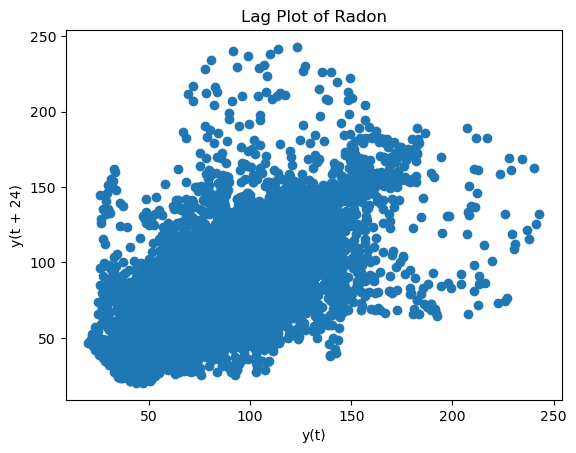

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

# Example: assume your DataFrame is df and column is 'radon'
lag_plot(df['radon'], lag=24)
plt.title("Lag Plot of Radon")
plt.show()


In [7]:
## Obviously lag features will be useful for our predictions

for lag in range(1, 11):
    corr = df['radon'].corr(df['radon'].shift(lag))
    print(f"Lag {lag}: {corr:.3f}")

Lag 1: 0.991
Lag 2: 0.971
Lag 3: 0.945
Lag 4: 0.917
Lag 5: 0.890
Lag 6: 0.868
Lag 7: 0.850
Lag 8: 0.834
Lag 9: 0.819
Lag 10: 0.806


In [8]:
for lag in range(4*24, 4*24 + 1):
    corr = df['radon'].corr(df['radon'].shift(lag))
    print(f"Lag {lag}: {corr:.3f}")

Lag 96: 0.276


In [9]:
from sklearn.linear_model import LinearRegression

# Training data
X = df.loc[:, ['Time']]  # features
y = df.loc[:, 'radon']  # target

# Train the model
model = LinearRegression()
model.fit(X, y)

# Store the fitted values as a time series with the same time index as
# the training data
y_pred = pd.Series(model.predict(X), index=X.index)

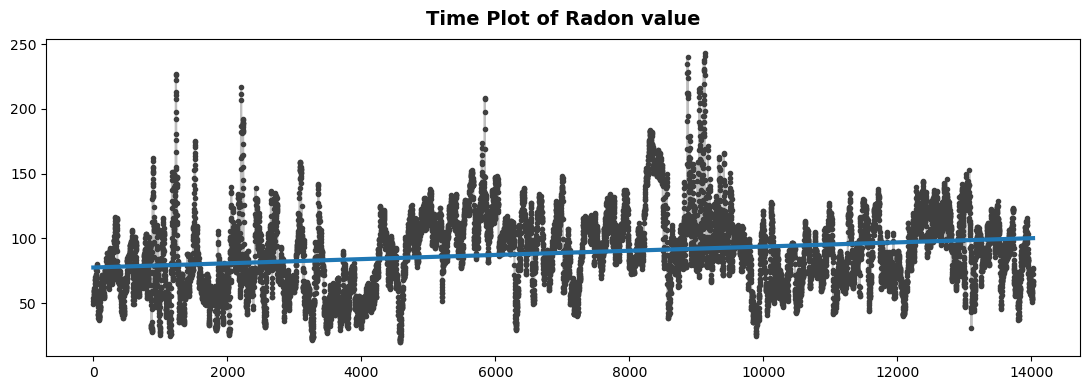

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# Set Matplotlib defaults
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

ax = y.plot(**plot_params)
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of Radon value');

In [11]:
print("Slope (m):     ", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (m):      0.0016161144823030609
Intercept (b): 77.52318333100507


In [12]:
df = df.dropna(subset=["salinity"])

In [13]:
df.isna().sum()

radon          0
salinity       0
temperature    0
year           0
month          0
day            0
hour           0
minute         0
Time           0
dtype: int64

In [14]:
df['Lag_1'] = df['radon'].shift(1)
df.head()

,radon,salinity,temperature,year,month,day,hour,minute,Time,Lag_1
0,49.57,33.65,17.14,2005,11,18,16,9,0,NaN
1,53.72,33.65,16.95,2005,11,18,17,9,1,49.57
2,51.37,33.66,17.14,2005,11,18,18,9,2,53.72
3,50.02,33.70,16.76,2005,11,18,19,9,3,51.37
4,51.81,33.72,16.57,2005,11,18,20,9,4,50.02


In [15]:
df = df.iloc[1:]  # drop first row

In [16]:
df.head()

,radon,salinity,temperature,year,month,day,hour,minute,Time,Lag_1
1,53.72,33.65,16.95,2005,11,18,17,9,1,49.57
2,51.37,33.66,17.14,2005,11,18,18,9,2,53.72
3,50.02,33.70,16.76,2005,11,18,19,9,3,51.37
4,51.81,33.72,16.57,2005,11,18,20,9,4,50.02
5,52.10,33.73,16.19,2005,11,18,21,9,5,51.81


In [17]:
from sklearn.linear_model import LinearRegression

X = df.loc[:, ['Lag_1']]
X.dropna(inplace=True)  # drop missing values in the feature set
y = df.loc[:, 'radon']  # create the target
y, X = y.align(X, join='inner')  # drop corresponding values in target

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

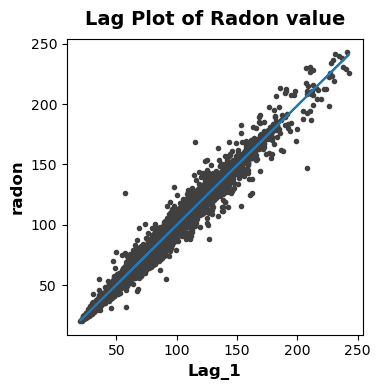

In [18]:
fig, ax = plt.subplots()
ax.plot(X['Lag_1'], y, '.', color='0.25')
ax.plot(X['Lag_1'], y_pred)
ax.set_aspect('equal')
ax.set_ylabel('radon')
ax.set_xlabel('Lag_1')
ax.set_title('Lag Plot of Radon value');

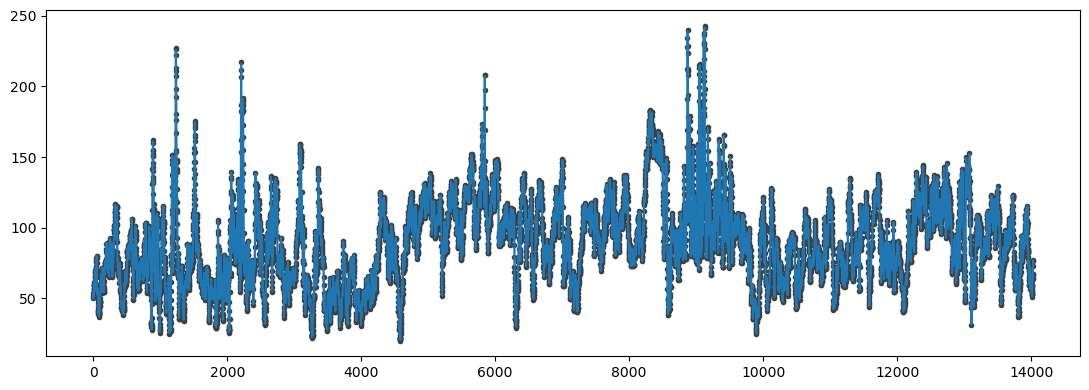

In [19]:
ax = y.plot(**plot_params)
ax = y_pred.plot()

In [20]:
df[-5:]

,radon,salinity,temperature,year,month,day,hour,minute,Time,Lag_1
14023,66.98,35.40,26.80,2007,10,15,5,35,14023,63.84
14024,67.06,35.44,26.50,2007,10,15,6,35,14024,66.98
14025,72.78,35.35,26.22,2007,10,15,8,35,14025,67.06
14026,76.67,35.41,26.79,2007,10,15,9,35,14026,72.78
14027,77.15,35.41,26.79,2007,10,15,9,52,14027,76.67


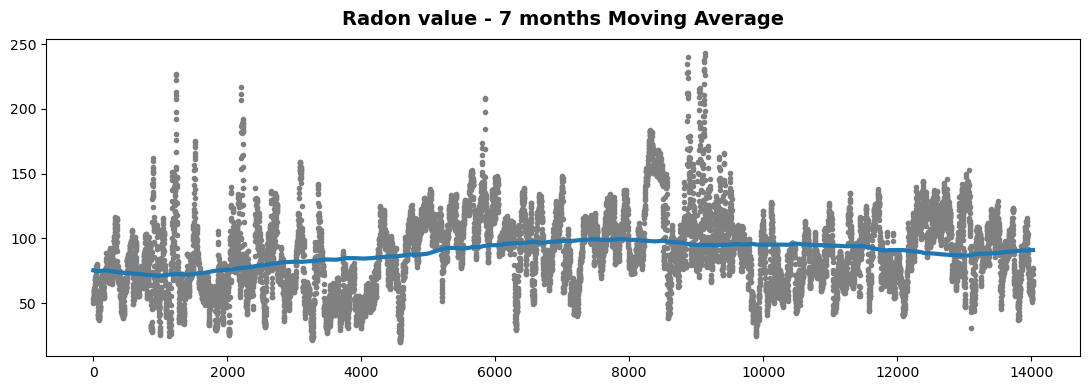

In [21]:
                                    ### Here we are working with Trend   ###
### Trend (from year to year… well for that we must have a lot of information)  - the slowest changes ###




moving_average = df['radon'].rolling(
    window=24*30*9,       # 7 months window
    center=True,      # puts the average at the center of the window
    min_periods=15,  # choose about half the window size
).mean()              # compute the mean (could also do median, std, min, max, ...)

ax = df['radon'].plot(style=".", color="0.5")
moving_average.plot(
    ax=ax, linewidth=3, title="Radon value - 7 months Moving Average", legend=False,
);

In [22]:
from statsmodels.tsa.deterministic import DeterministicProcess

dp = DeterministicProcess(
    index=df['radon'].index,  # dates from the training data
    constant=True,       # dummy feature for the bias (y_intercept)
    order=1,             # the time dummy (trend)
    drop=True,           # drop terms if necessary to avoid collinearity
)
# `in_sample` creates features for the dates given in the `index` argument
X = dp.in_sample()

X.head()

,const,trend
1,1.0,1.0
2,1.0,2.0
3,1.0,3.0
4,1.0,4.0
5,1.0,5.0


In [23]:
from sklearn.linear_model import LinearRegression

y = df['radon']  # the target

# The intercept is the same as the `const` feature from
# DeterministicProcess. LinearRegression behaves badly with duplicated
# features, so we need to be sure to exclude it here.
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

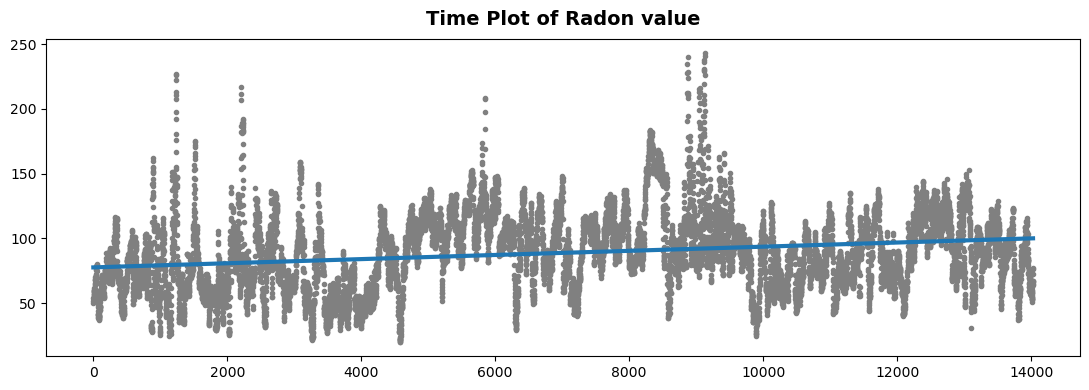

In [24]:
ax = df['radon'].plot(style=".", color="0.5", title="Time Plot of Radon value")
_ = y_pred.plot(ax=ax, linewidth=3, label="Trend")

In [25]:
X = dp.out_of_sample(steps=300)

y_fore = pd.Series(model.predict(X), index=X.index)

y_fore.head()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


14005    100.049711
14006    100.051314
14007    100.052918
14008    100.054521
14009    100.056125
dtype: float64

In [26]:
len(y_fore) 

300

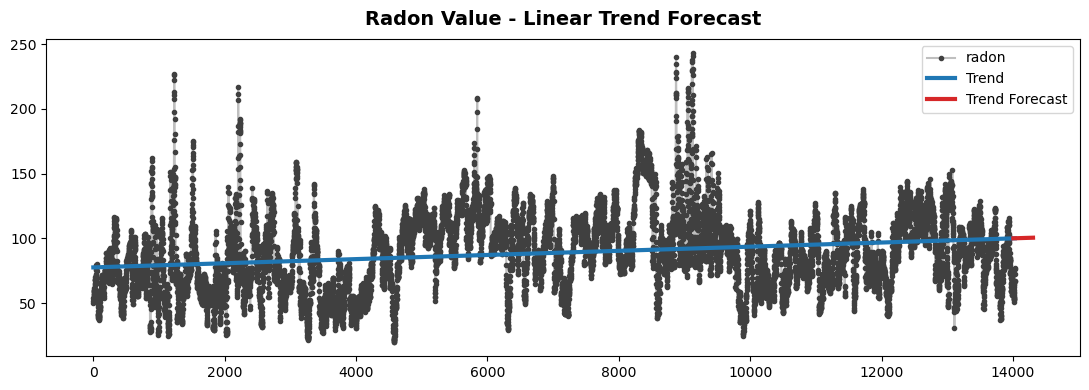

In [27]:
ax = df['radon'].plot(title="Radon Value - Linear Trend Forecast", **plot_params)
ax = y_pred.plot(ax=ax, linewidth=3, label="Trend")
ax = y_fore.plot(ax=ax, linewidth=3, label="Trend Forecast", color="C3")
_ = ax.legend()

In [28]:
### SASONALITY ###
import numpy as np


def fourier_features(index, freq, order):
    time = np.arange(len(index), dtype=np.float32)
    k = 2 * np.pi * (1 / freq) * time
    features = {}
    for i in range(1, order + 1):
        features.update({
            f"sin_{freq}_{i}": np.sin(i * k),
            f"cos_{freq}_{i}": np.cos(i * k),
        })
    return pd.DataFrame(features, index=index)


# Compute Fourier features to the 4th order (8 new features) for a
# series y with daily observations and annual seasonality:
#
# fourier_features(y, freq=365.25, order=4)

In [29]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax






def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax




In [30]:
df.head()

,radon,salinity,temperature,year,month,day,hour,minute,Time,Lag_1
1,53.72,33.65,16.95,2005,11,18,17,9,1,49.57
2,51.37,33.66,17.14,2005,11,18,18,9,2,53.72
3,50.02,33.70,16.76,2005,11,18,19,9,3,51.37
4,51.81,33.72,16.57,2005,11,18,20,9,4,50.02
5,52.10,33.73,16.19,2005,11,18,21,9,5,51.81


In [31]:
df["weekday_num"] = pd.to_datetime(df[["year", "month", "day"]]).dt.weekday


In [32]:
df["week_num"] = pd.to_datetime(df[["year", "month", "day"]]).dt.isocalendar().week


In [33]:
df.head()

,radon,salinity,temperature,year,month,day,hour,minute,Time,Lag_1,weekday_num,week_num
1,53.72,33.65,16.95,2005,11,18,17,9,1,49.57,4,46
2,51.37,33.66,17.14,2005,11,18,18,9,2,53.72,4,46
3,50.02,33.70,16.76,2005,11,18,19,9,3,51.37,4,46
4,51.81,33.72,16.57,2005,11,18,20,9,4,50.02,4,46
5,52.10,33.73,16.19,2005,11,18,21,9,5,51.81,4,46


In [34]:
# given from your regression
m = 0.0016161144823030609
b = 77.52318333100507

# compute the trend component
df["trend"] = m * df["Time"] + b

# subtract trend from original radon values
df["radon_detrended"] = df["radon"] - df["trend"]

In [35]:
df.head()

,radon,salinity,temperature,year,month,day,hour,minute,Time,Lag_1,weekday_num,week_num,trend,radon_detrended
1,53.72,33.65,16.95,2005,11,18,17,9,1,49.57,4,46,77.524799,-23.804799
2,51.37,33.66,17.14,2005,11,18,18,9,2,53.72,4,46,77.526416,-26.156416
3,50.02,33.70,16.76,2005,11,18,19,9,3,51.37,4,46,77.528032,-27.508032
4,51.81,33.72,16.57,2005,11,18,20,9,4,50.02,4,46,77.529648,-25.719648
5,52.10,33.73,16.19,2005,11,18,21,9,5,51.81,4,46,77.531264,-25.431264


/var/folders/2g/xhc9l265581fbqnpvs1x3g2m0000gn/T/ipykernel_5030/3922148937.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  ax = sns.lineplot(
/var/folders/2g/xhc9l265581fbqnpvs1x3g2m0000gn/T/ipykernel_5030/3922148937.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  ax = sns.lineplot(
/var/folders/2g/xhc9l265581fbqnpvs1x3g2m0000gn/T/ipykernel_5030/3922148937.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  ax = sns.lineplot(


<Axes: title={'center': 'Seasonal Plot (year/day_of_year)'}, xlabel='day_of_year', ylabel='radon_detrended'>

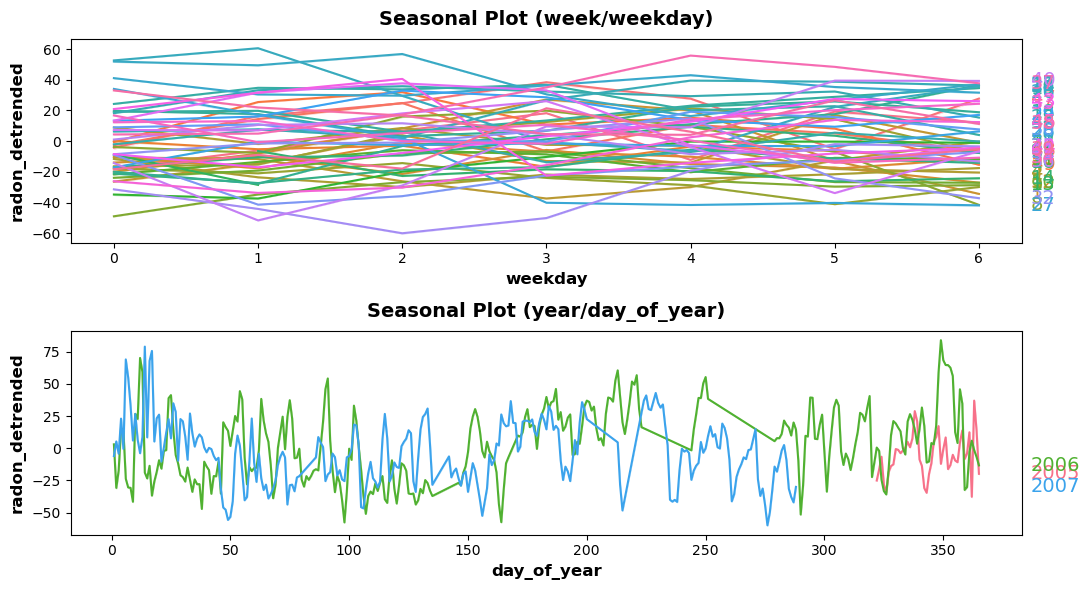

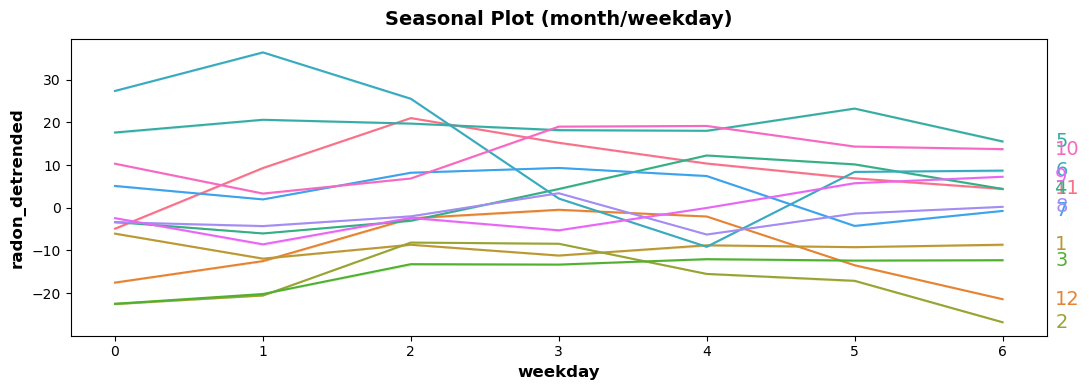

In [36]:
# --- FIXED VERSION ---

X = df.copy()

# ✅ Do NOT overwrite calendar 'day'. Use new columns.
X["weekday"] = X["weekday_num"].astype(int)   # 0–6 (Mon–Sun)
X["week"]    = X["week_num"].astype(int)      # ISO week number

# ✅ Build a safe datetime from Y/M/D and get day-of-year
dt = pd.to_datetime(
    dict(
        year=X["year"].astype(int),
        month=X["month"].astype(int),
        day=X["day"].astype(int),
    ),
    errors="coerce",
)
X["day_of_year"] = dt.dt.dayofyear

# (optional) sanity checks
# assert X["day"].between(1, 31).all()
# assert X["day_of_year"].notna().all()

# --- plots ---
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 6))

# seasonality within a week (x-axis: weekday; period groups: week)
seasonal_plot(X, y="radon_detrended", period="week", freq="weekday", ax=ax0)



seasonal_plot(X, y="radon_detrended", period="month", freq="weekday")


# seasonality within a year (x-axis: day_of_year; period groups: year)
seasonal_plot(X, y="radon_detrended", period="year", freq="day_of_year", ax=ax1)


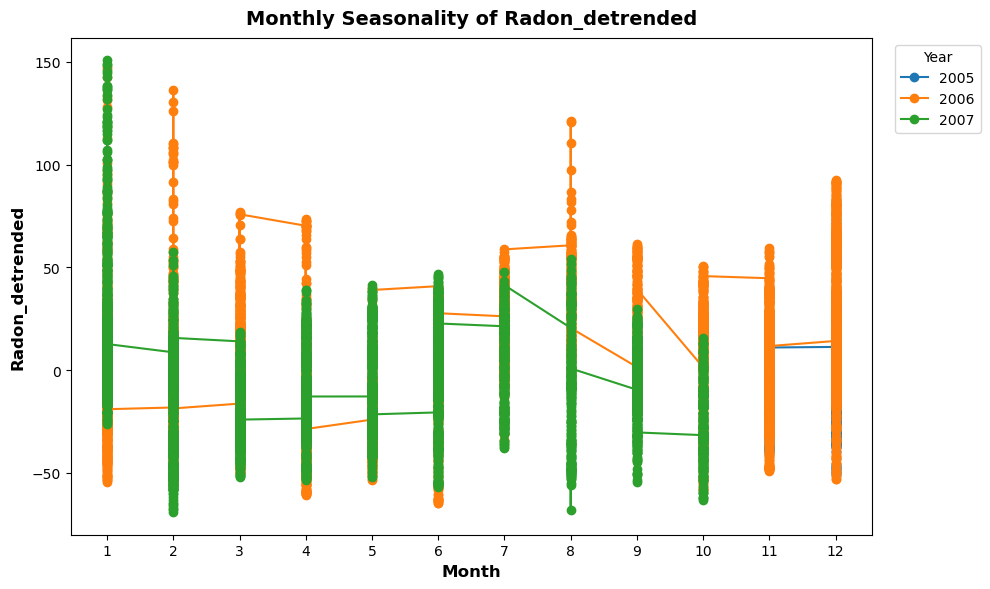

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# --- assume you already have df with columns:
# 'radon', 'year', 'month', 'day', 'hour', 'minute', 'weekday_num', 'week_num'

# 1) Work on a copy
X = df.copy()

# 2) Build a real datetime index from year / month / day / hour / minute
X['dt'] = pd.to_datetime(
    dict(
        year=X['year'],
        month=X['month'],
        day=X['day'],
        hour=X['hour'],
        minute=X['minute'],
    ),
    errors='coerce'
)

X = X.set_index('dt').sort_index()

# 3) Extract year and month from the datetime index
X['year'] = X.index.year
X['month'] = X.index.month

# 4) Monthly seasonality plot: x = month (1–12), each line = one year
fig, ax = plt.subplots(figsize=(10, 6))

for y, g in X.groupby('year'):
    ax.plot(g['month'], g['radon_detrended'], marker='o', label=str(y))

ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Radon_detrended")
ax.set_title("Monthly Seasonality of Radon_detrended")
ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [38]:
### Radon does NOT depend strongly on the day of the week. Weekly seasonality is not meaningful###
### Clear annual structure. Winters (~day 0–80 & ~330–365). Summers (~day 120–250): Lower and more stable radon ###

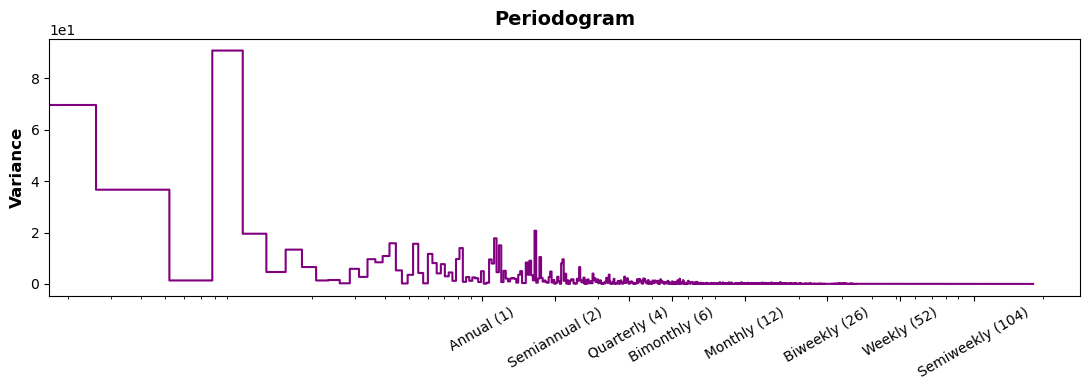

In [39]:
plot_periodogram(df.radon_detrended);

In [40]:
# Cycles
# The goal in this lesson is to train models to fit curves to plots like those on the right -- we want them to learn serial dependence
# cycle is less about the particular date of occurence, and more about what has happened in the recent past.

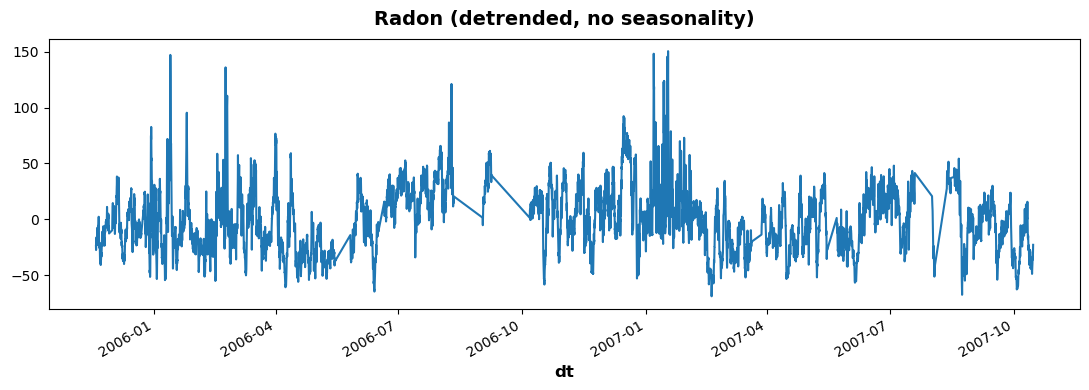

In [41]:
# --- your existing setup ---
radon_df = df.copy()

radon_df['dt'] = pd.to_datetime(
    dict(
        year=radon_df['year'],
        month=radon_df['month'],
        day=radon_df['day'],
        hour=radon_df['hour'],
        minute=radon_df['minute'],
    )
)

radon_df = radon_df.set_index('dt')
y = radon_df['radon']


# ------
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression

dp = DeterministicProcess(
    index=y.index,
    constant=True,   # intercept
    order=1,         # linear trend (remove if unwanted)
    seasonal=False,  # ❗ no seasonality
    drop=True,
)

X_time = dp.in_sample()

model = LinearRegression(fit_intercept=False)
model.fit(X_time, y)

y_detrended = y - model.predict(X_time)
y_detrended.name = 'radon_detrended'

ax = y_detrended.plot()
ax.set_title("Radon (detrended, no seasonality)");


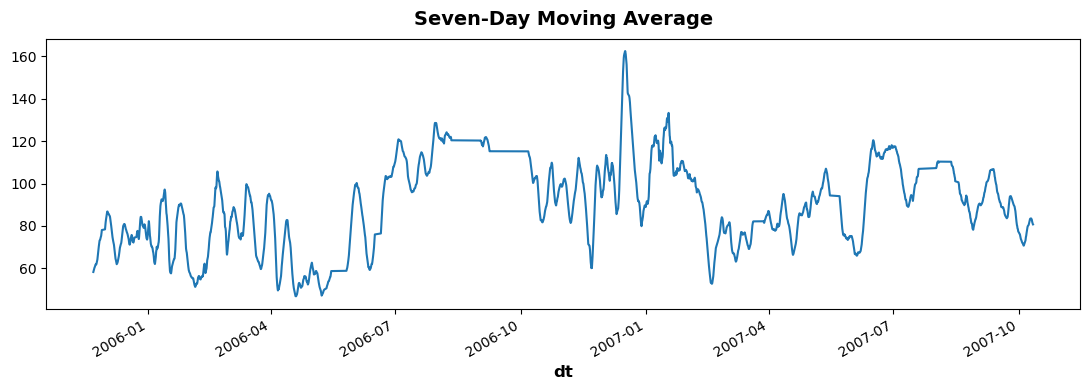

In [42]:
# Now let us look at cycles
y_ma = y.rolling(24*7, center=True).mean()

ax = y_ma.plot()
ax.set_title("Seven-Day Moving Average");



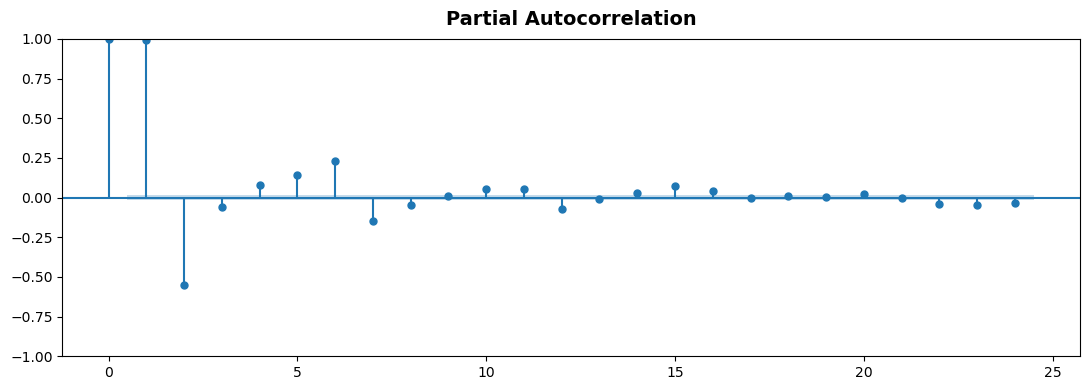

In [43]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(y_detrended, lags=24);


In [49]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_lags_pretty(y, lags=8, ncols=4, figsize=(12, 6)):
    """
    Scatter y(t-k) vs y(t) with LOWESS red line and Pearson r.
    """
    nrows = int(np.ceil(lags / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for i in range(lags):
        lag = i + 1
        ax = axes[i]

        # build dataframe
        df = pd.DataFrame({
            "y": y,
            "y_lag": y.shift(lag)
        }).dropna()

        # scatter
        ax.scatter(df["y_lag"], df["y"], s=10, alpha=0.6)

        # LOWESS smoother (explicit red)
        smoothed = lowess(df["y"], df["y_lag"], frac=0.3, it=0)
        ax.plot(smoothed[:, 0], smoothed[:, 1],
                linewidth=2, color="red")

        # correlation coefficient box
        r = df["y"].corr(df["y_lag"])
        ax.text(
            0.05, 0.85, f"{r:.2f}",
            transform=ax.transAxes,
            bbox=dict(boxstyle="round", fc="white", ec="black"),
            fontsize=10
        )

        # formatting
        ax.set_title(f"Lag {lag}", fontsize=11)
        ax.set_xlabel(y.name or "y", fontsize=9)
        ax.set_ylabel(y.name or "y", fontsize=9)
        ax.grid(True, alpha=0.2)

        # 🔥 force square plot
        ax.set_aspect("equal", adjustable="box")

    # turn off unused axes
    for j in range(lags, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



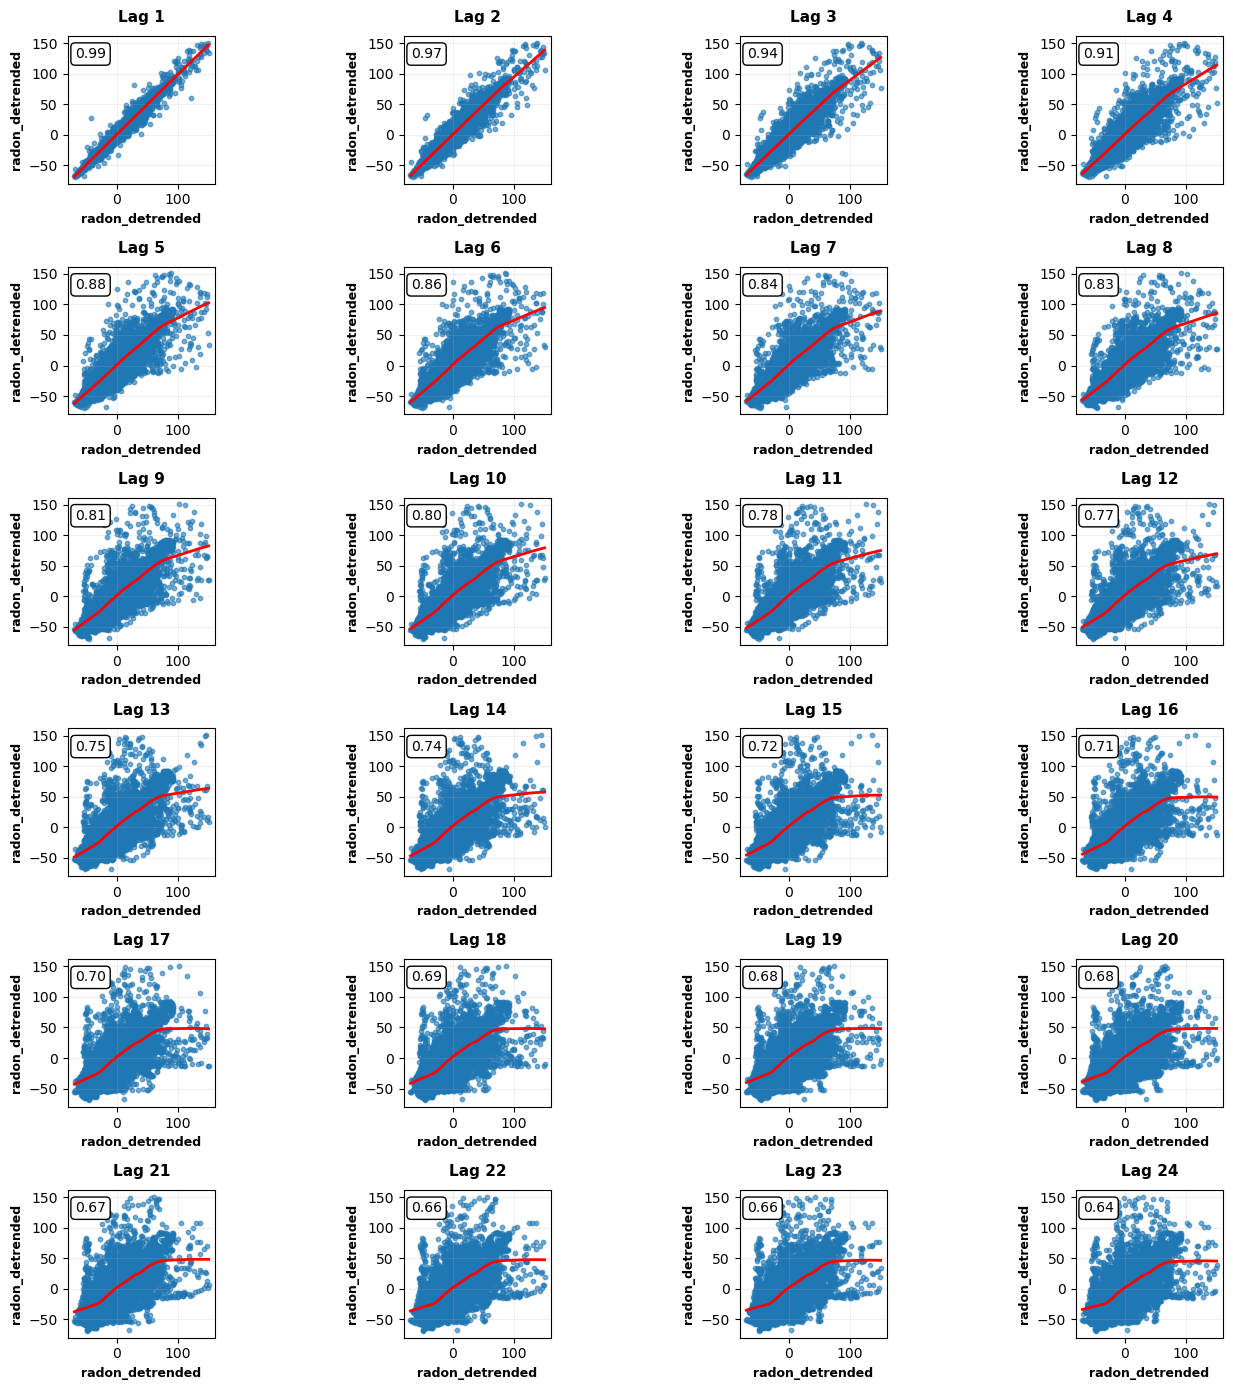

In [50]:
plot_lags_pretty(y_detrended, lags=24, ncols=4, figsize=(14, 14))

In [ ]:
# Now it's time to use what we've learn to make our first prediction and then see what is the residual